In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, udf, abs, mean, stddev, expr
from pyspark.sql.types import TimestampType, StringType
import os
import cudf
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import random
import time

spark = (SparkSession.builder
    .appName("GPU_Optimized_RAPIDS")
    .master("local[*]")
    .config("spark.driver.memory","24g")
    .config("spark.executor.memory", "24g")
    .config("spark.executor.cores", "4")
    .config("spark.driver.cores", "4")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.plugins", "com.nvidia.spark.SQLPlugin")
    .config("spark.driver.host", "localhost")
    .config("spark.rapids.sql.explain", "ALL")
    .config("spark.rapids.sql.allowMultipleJars", "ALWAYS")
    .config("spark.rapids.sql.enabled", "true")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.rapids.sql.exec.CollectLimitExec", "true")
    .config("spark.rapids.sql.rowBasedUDF.enabled", "true")
    .config("spark.sql.inMemoryColumnarStorage.batchSerializer", "com.nvidia.spark.rapids.shims.SparkShimServiceProvider")
    .config("spark.jars.packages", "com.nvidia:rapids-4-spark_2.13:26.02.0")
    .config("spark.rapids.memory.pinnedPool.size", "1G") 
    .config("spark.rapids.memory.gpu.allocation.limit", "0.7")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/04 20:21:24 WARN Utils: Your hostname, DESKTOP-15VE119, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/04 20:21:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/berenunveren/miniconda3/envs/bigdata_env/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/berenunveren/.ivy2.5.2/cache
The jars for the packages stored in: /home/berenunveren/.ivy2.5.2/jars
com.nvidia#rapids-4-spark_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d1f2e2c0-e6de-4228-9a40-c5b23078a4c9;1.0
	confs: [default]
	found com.nvidia#rapids-4-spark_2.13;26.02.0 in central
:: resolution report :: resolve 85ms :: artifacts dl 2ms
	:: modules in use:
	com.nvidia#rapids-4-spark_2.13;26.02.0 from cen

In [2]:
n_rows_benchmark = 1_000_000 
categories = ['Electronics', 'Clothing', 'Home', 'Books', 'Garden']
price_map_values = [400.0, 60.0, 150.0, 20.0, 80.0]

print(f"Starting CPU Benchmark for {n_rows_benchmark:,} rows...")
start_cpu = time.time()
cpu_df = pd.DataFrame({'id': np.arange(n_rows_benchmark)})
cpu_cat_indices = np.random.randint(0, len(categories), n_rows_benchmark)
cpu_df['category'] = np.array(categories)[cpu_cat_indices]
cpu_price_map = np.array(price_map_values)
cpu_df['unit_price'] = (cpu_price_map[cpu_cat_indices] + np.random.normal(0, 15, n_rows_benchmark)).round(2)
cpu_df['quantity'] = np.random.randint(1, 10, n_rows_benchmark)
start_date = np.datetime64('2026-01-01')
random_seconds = np.random.randint(0, 365*24*60*60, n_rows_benchmark).astype('timedelta64[s]')
cpu_df['purchase_date'] = start_date + random_seconds
cpu_df['total_spent'] = (cpu_df['unit_price'] * cpu_df['quantity']).round(2)
end_cpu = time.time()
cpu_duration = end_cpu - start_cpu
print(f"CPU Generation Time: {cpu_duration:.4f} seconds")


print(f"\nStarting GPU Benchmark for {n_rows_benchmark:,} rows...")
start_gpu = time.time()
gdf = cudf.DataFrame({'id': cp.arange(n_rows_benchmark)})
gpu_cat_indices = cp.random.randint(0, len(categories), n_rows_benchmark)
gdf['category'] = cudf.Series(categories).take(gpu_cat_indices).reset_index(drop=True)
gpu_price_map = cp.array(price_map_values)
gdf['unit_price'] = (cudf.Series(gpu_price_map).take(gpu_cat_indices).reset_index(drop=True) + cp.random.normal(0, 15, n_rows_benchmark)).round(2)
gdf['unit_price'] = gdf['unit_price'].clip(lower=0.01)
gdf['quantity'] = cp.random.randint(1, 10, n_rows_benchmark)
start_timestamp_2026 = int(pd.Timestamp('2026-01-01').timestamp())
gpu_offsets = cp.random.randint(0, 365*24*60*60, n_rows_benchmark, dtype=cp.int64)
gdf['purchase_date'] = cudf.Series(gpu_offsets + start_timestamp_2026).astype('datetime64[s]')
gdf['total_spent'] = (gdf['unit_price'] * gdf['quantity']).round(2)
end_gpu = time.time()
gpu_duration = end_gpu - start_gpu
print(f"GPU Generation Time: {gpu_duration:.4f} seconds")
speedup = cpu_duration / gpu_duration
print(f"GPU is {speedup:.2f}x faster than CPU")



quantity_lambdas = [1.2, 2.5, 1.8, 4.5, 2.2]
print(f"\nStarting Enhanced GPU Benchmark for {n_rows_benchmark:,} rows...")
start_gpu_enhanced = time.time()
gdf = cudf.DataFrame({'id': cp.arange(n_rows_benchmark)})
cat_indices = cp.random.randint(0, len(categories), n_rows_benchmark)
gdf['category'] = cudf.Series(categories).take(cat_indices).reset_index(drop=True)
means_arr = cp.array(price_map_values)[cat_indices]
gdf['unit_price'] = (means_arr + cp.random.normal(0, 15, n_rows_benchmark)).round(2)
gdf['unit_price'] = gdf['unit_price'].clip(lower=0.50)
lams_arr = cp.array(quantity_lambdas)[cat_indices]
gdf['quantity'] = cp.random.poisson(lams_arr, n_rows_benchmark).astype(cp.int32)
gdf['quantity'] = gdf['quantity'].clip(lower=1)

start_ts = int(pd.Timestamp('2026-01-01').timestamp())
seconds_in_year = 365 * 24 * 60 * 60
offsets = cp.random.randint(0, seconds_in_year, n_rows_benchmark, dtype=cp.int64)
date_series = cudf.Series(offsets + start_ts).astype('datetime64[s]')
day_of_week = date_series.dt.dayofweek
weekday_mask = day_of_week < 5
move_mask = (weekday_mask & (cp.random.random(n_rows_benchmark) < 0.30)).values
seconds_per_day = 24 * 60 * 60
nudge_seconds = (5 - day_of_week[move_mask].astype('int64')) * seconds_per_day
offsets[move_mask] += nudge_seconds.values  
offsets = offsets.clip(0, seconds_in_year - 1)

gdf['purchase_date'] = cudf.Series(offsets + start_ts).astype('datetime64[s]')
gdf['total_spent'] = (gdf['unit_price'] * gdf['quantity']).round(2)
end_gpu_enhanced = time.time()
gpu_duration_enhanced = end_gpu_enhanced - start_gpu_enhanced
print(f"Enhanced GPU Generation Time: {gpu_duration_enhanced:.4f} seconds")
speedup = cpu_duration / gpu_duration_enhanced
print(f"GPU is {speedup:.2f}x faster than CPU on the second time")


output_dir = "/home/berenunveren/assignment_output/"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "dataset.csv")
parquet_path = os.path.join(output_dir, "dataset.parquet")
gdf.to_csv(csv_path, index=False)
gdf.to_parquet(parquet_path)
csv_size = os.path.getsize(csv_path) / (1024 * 1024)
parquet_size = os.path.getsize(parquet_path) / (1024 * 1024)

print(f"\nFile Size Comparison:")
print(f"CSV Format:     {csv_size:.2f} MB")
print(f"Parquet Format: {parquet_size:.2f} MB ({(1 - parquet_size/csv_size)*100:.1f}% smaller)")


Starting CPU Benchmark for 1,000,000 rows...
CPU Generation Time: 0.1994 seconds

Starting GPU Benchmark for 1,000,000 rows...
GPU Generation Time: 0.4656 seconds
GPU is 0.43x faster than CPU

Starting Enhanced GPU Benchmark for 1,000,000 rows...
Enhanced GPU Generation Time: 0.1222 seconds
GPU is 1.63x faster than CPU on the second time

File Size Comparison:
CSV Format:     48.16 MB
Parquet Format: 15.59 MB (67.6% smaller)


In [3]:

print("\nGPU Dataset Statistics:")
print(gdf[["unit_price", "quantity", "total_spent", "purchase_date"]].describe())

print("\nCategory Distribution:")
cat_dist = gdf.groupby("category").size().to_frame("count").sort_values("count", ascending=False)
print(cat_dist)

mask = (gdf["total_spent"] - (gdf["unit_price"] * gdf["quantity"])).abs() > 0.01
errors = len(gdf[mask])
print(f"Consistency Errors: {errors}")


GPU Dataset Statistics:
           unit_price        quantity     total_spent        purchase_date
count  1000000.000000  1000000.000000  1000000.000000              1000000
mean       142.357922        2.570578      265.803924  2026-07-03 05:15:00
min          0.500000        1.000000        0.500000  2026-01-01 00:01:51
25%         49.960000        1.000000       95.130000  2026-04-03 18:52:02
50%         82.660000        2.000000      174.570000  2026-07-03 23:27:46
75%        160.330000        3.000000      385.440000  2026-10-03 05:13:52
max        465.940000       18.000000     3943.710000  2026-12-31 23:59:59
std        136.507910        1.773449      258.398404                 <NA>

Category Distribution:
              count
category           
Electronics  200629
Garden       200599
Home         199787
Books        199733
Clothing     199252
Consistency Errors: 0


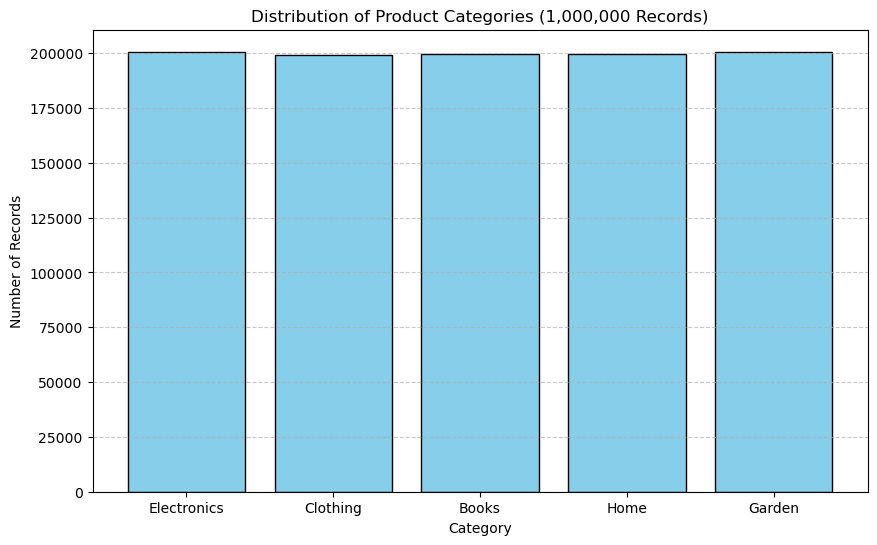

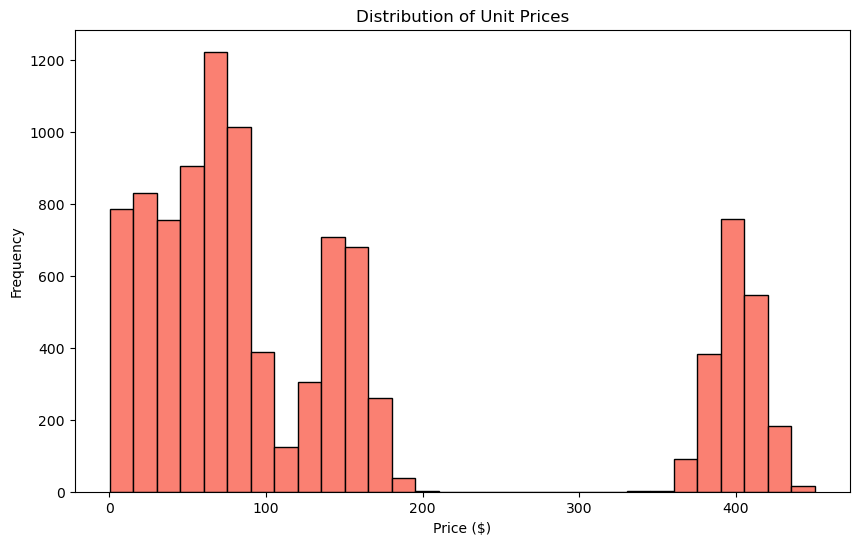

In [4]:
cat_dist = gdf.groupby("category").size().to_frame("count").reset_index().to_pandas()
plt.figure(figsize=(10, 6))
plt.bar(cat_dist['category'], cat_dist['count'], color='skyblue', edgecolor='black')
plt.title('Distribution of Product Categories (1,000,000 Records)')
plt.xlabel('Category')
plt.ylabel('Number of Records')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

prices = gdf.sample(frac=0.01, replace=False).to_pandas()
plt.figure(figsize=(10, 6))
plt.hist(prices['unit_price'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Unit Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


Statistical Overview:
                   id      unit_price        quantity        purchase_date  \
count  1000000.000000  1000000.000000  1000000.000000              1000000   
mean    499999.500000      142.357922        2.570578  2026-07-03 05:15:00   
min          0.000000        0.500000        1.000000  2026-01-01 00:01:51   
25%     249999.750000       49.960000        1.000000  2026-04-03 18:52:02   
50%     499999.500000       82.660000        2.000000  2026-07-03 23:27:46   
75%     749999.250000      160.330000        3.000000  2026-10-03 05:13:52   
max     999999.000000      465.940000       18.000000  2026-12-31 23:59:59   
std     288675.278932      136.507910        1.773449                 <NA>   

          total_spent  
count  1000000.000000  
mean       265.803924  
min          0.500000  
25%         95.130000  
50%        174.570000  
75%        385.440000  
max       3943.710000  
std        258.398404  


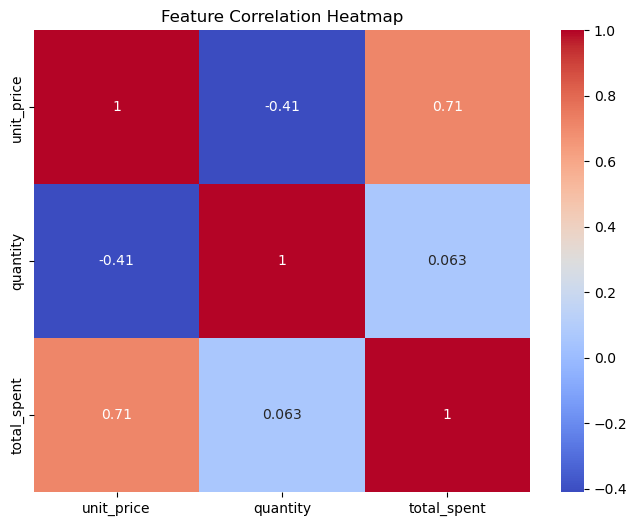

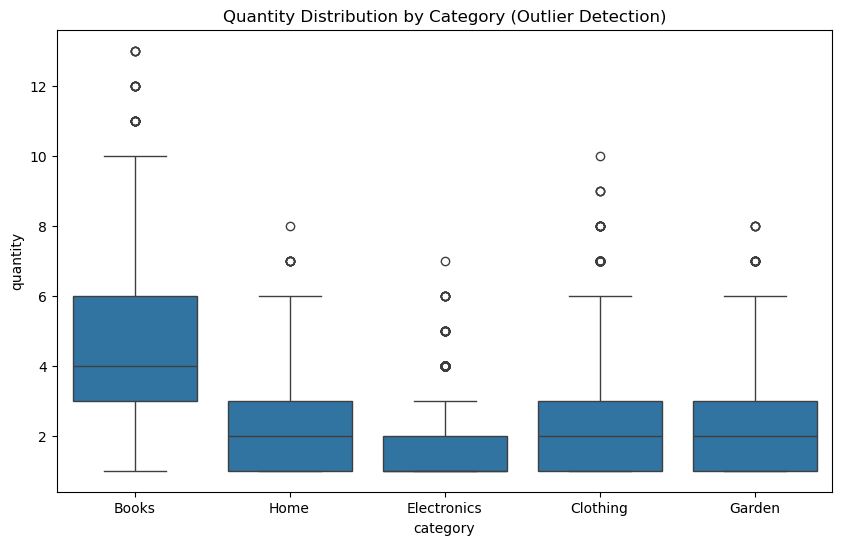

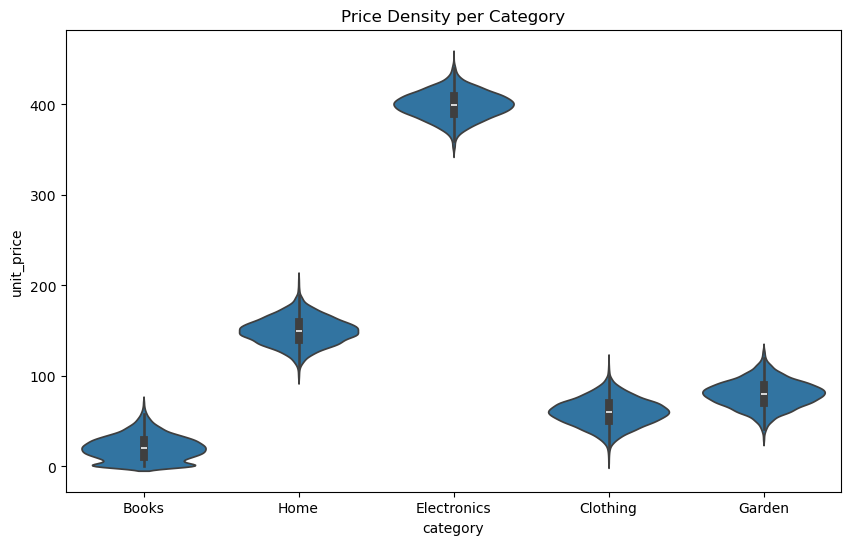

In [5]:
print("\nStatistical Overview:")
print(gdf.describe())

pdf = gdf.sample(frac=0.02, replace=False).to_pandas()

plt.figure(figsize=(8, 6))
sns.heatmap(pdf[['unit_price', 'quantity', 'total_spent']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='quantity', data=pdf)
plt.title("Quantity Distribution by Category (Outlier Detection)")
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(x='category', y='unit_price', data=pdf)
plt.title("Price Density per Category")
plt.show()

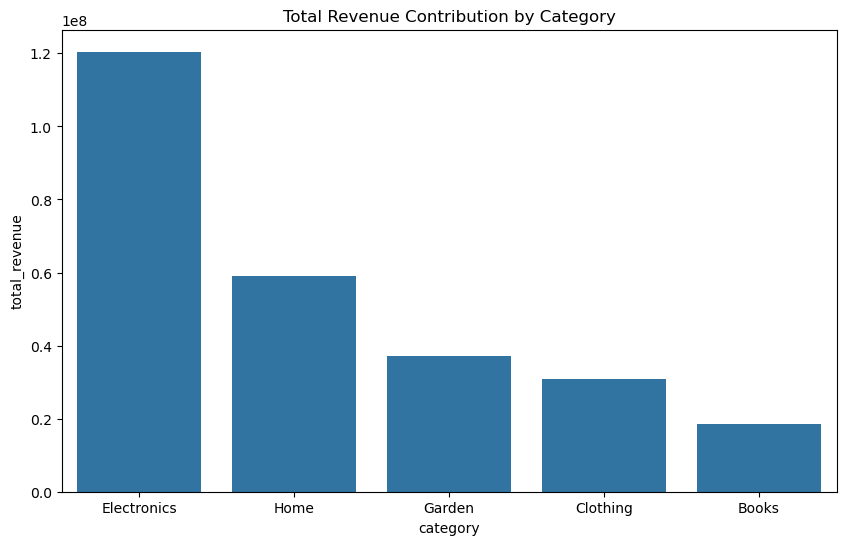

Number of mathematically detected quantity outliers: 18679


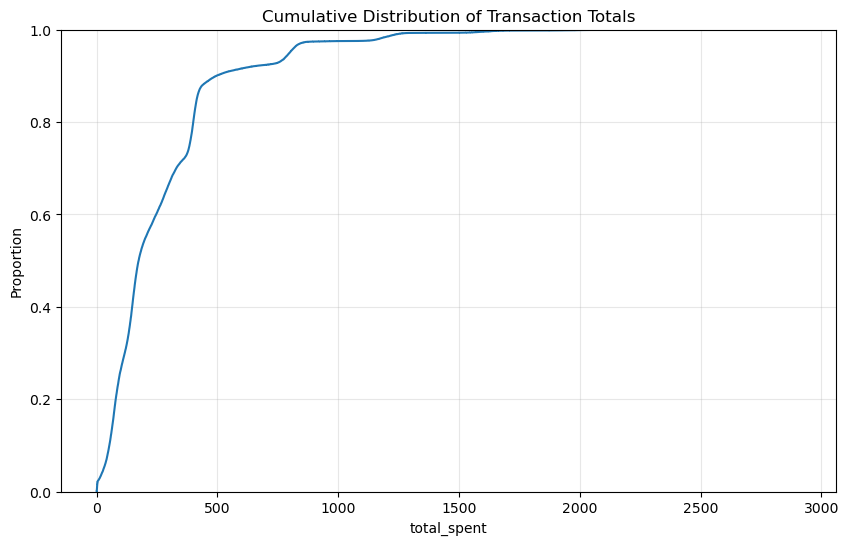

In [6]:
rev_dist = gdf.groupby("category")["total_spent"].sum().reset_index().to_pandas()
rev_dist = rev_dist.rename(columns={"total_spent": "total_revenue"})

plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='total_revenue', data=rev_dist.sort_values('total_revenue', ascending=False))
plt.title('Total Revenue Contribution by Category')
plt.show()


mu = gdf["quantity"].mean()
sigma = gdf["quantity"].std()
outliers_mask = ((gdf["quantity"] - mu) / sigma) > 3
outliers_count = len(gdf[outliers_mask])
print(f"Number of mathematically detected quantity outliers: {outliers_count}")


spend_data = gdf[["total_spent"]].sample(frac=0.05).to_pandas()
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=spend_data, x='total_spent')
plt.title('Cumulative Distribution of Transaction Totals')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
print("Example Data Rows:")
print(gdf.head(5))

null_counts = gdf.isnull().sum().sum()
assert null_counts == 0, f"Failure: Found {null_counts} missing values."

diff = (gdf['total_spent'] - (gdf['unit_price'] * gdf['quantity'])).abs()
assert (diff < 0.02).all(), "Failure: Total spent does not match unit_price * quantity."

min_date = gdf['purchase_date'].min()
max_date = gdf['purchase_date'].max()
assert min_date >= pd.Timestamp('2026-01-01'), f"Failure: Date {min_date} is before 2026."
assert max_date <= pd.Timestamp('2026-12-31 23:59:59'), f"Failure: Latest date {max_date} is after 2026."
print(f"Data covers {pd.Timedelta(max_date - min_date).days} days of the year 2026.")

counts = gdf['purchase_date'].dt.dayofweek.value_counts().to_pandas().sort_index()
weekend_avg = (counts[5] + counts[6]) / 2
weekday_avg = counts.loc[0:4].mean()
assert weekend_avg > weekday_avg, "Warning: Weekend spike not detected."

book_qty = gdf[gdf['category'] == 'Books']['quantity'].mean()
elec_qty = gdf[gdf['category'] == 'Electronics']['quantity'].mean()
assert book_qty > elec_qty, "Failure: Poisson distribution not reflecting categorical differences."


Example Data Rows:
   id  category  unit_price  quantity       purchase_date  total_spent
0   0     Books       24.21         4 2026-10-17 10:34:13        96.84
1   1  Clothing       34.00         4 2026-02-02 13:03:19       136.00
2   2    Garden       83.59         2 2026-11-06 07:41:09       167.18
3   3  Clothing       58.01         1 2026-12-31 23:59:59        58.01
4   4  Clothing       67.31         4 2026-07-25 21:24:53       269.24
Data covers 364 days of the year 2026.
